In [5]:
import cv2, matplotlib.pyplot as plt, numpy as np

In [ ]:
"""
Understaning intersection and coordinates:

        boxes:
        1:                                  2:
                        width = w                       width = w
        ┌─────────────────────┐             ┌─────────────────────┐
        │                     │ ↑           │                     │ ↑
        │                     │ │           │                     │ │
        │                     │ height      │                     │ height
        │                     │ = h         │                     │ = h
        │                     │ │           │                     │ │
        │                     │ ↓           │                     │ ↓
        └─────────────────────┘             └─────────────────────┘

      
        ---------------------------------------------------------------------------------------
        intersection: 
        ┌─────────────────────┐
        │                     │
        │        (x1, y1 )    │
        │           ┌─────────────────────┐
        │           |         │           │
        │           │         │           │
        │           │         │           │
        └─────────────────────┘(x2, y2)   │    
                    │                     │
                    │                     │
                    └─────────────────────┘              
        
        
        ---------------------------------------------------------------------------------------
         final x, y for intersection:
    
             (x1 , y1)  ┌───────────────┐
                        │               │
                        │  Intersection │
                        │               │
                        └─────────── (x2 , y2)
                        
        ---------------------------------------------------------------------------------------
        x, increases towards right
        y, increased towards bottom
        
        
                                ┌────────────── →  x increases →
                y increases ↓   │
                                │
                                ↓
                 
        ---------------------------------------------------------------------------------------
        x, decreases towards left
        y, decreases towards top

                ←  x decreases ← ───────────────┐
                                                │
                                                │
                                                │
                                                │ ↑  y decreases
                                                │
                                                ↓
                                           (0,0)

        --------------------------------------------------------------------------------------- """

In [ ]:
def calculate_iou(box1, box2):
    # intersection co-ords
    x1 = max(box1[0], box2[0])
    y1= max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box2[3], box2[3])
    
    # no overlap
    if x2 < x1 or y2 < y1:
        return 0.0
    
    # intersection area
    intersection_area = (x2 - x1) * (y2- y1)
    
    # boxes area
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    
    # intersection over union 
    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

In [17]:
# example
box1 = [50, 50, 200, 200]
box2 = [100, 100, 250, 250]

iou = calculate_iou(box1, box2)
print("iou = ", iou)

iou =  0.5


Text(0.5, 1.0, 'IOU: 0.50')

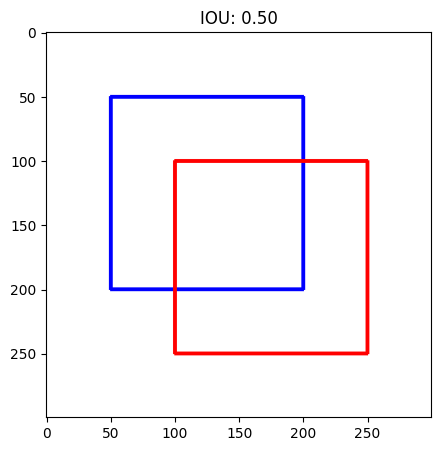

In [19]:
# visualize
# canvas
image = 255 * np.ones((300, 300, 3), dtype=np.uint8)

# cv2.rectangle(image, (x1, y1), (x2, y2), color, thickness)

# box1 blue
cv2.rectangle(image, (box1[0], box1[1]), (box1[2], box1[3]), (255, 0, 0), 2)

# box2 red
cv2.rectangle(image,(box2[0], box2[1]),(box2[2], box2[3]),(0, 0, 255),2)

# plot image
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title(f"IOU: {iou:.2f}")
